# 01 — Extracción de crops

Ejecutar el pipeline de extracción de frames del dataset UTA-RLDD y
visualizar la distribución resultante.

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## 1. Extraer crops

**Ajustar `DATA_DIR`** al directorio donde se descargó UTA-RLDD.

Estructura esperada (organizada por sujeto):
```
data/raw/
  01/  → 0.mov (alerta), 5.mov (baja vig.), 10.MOV (somnoliento)
  02/  → idem
  ...
  60/  → idem
```

Salida: `crops.h5` (HDF5, escritura incremental — RAM constante).

In [2]:
from src.data.extract_crops import extract_all

DATA_DIR = Path('../data/raw')
OUTPUT   = Path('../data/processed/crops.h5')
STRIDE   = 12   # 1 frame cada 12 → ~2.5 fps de un video a 30fps

extract_all(DATA_DIR, OUTPUT, stride=STRIDE)

Sujetos encontrados: 43

Sujeto 01:
  nivel 0 → 0.mov ... 1500 crops
  nivel 5 → 5.mov ... 1493 crops
  nivel 10 → 10.MOV ... 1472 crops

Sujeto 02:
  nivel 0 → 0.mov ... 1520 crops
  nivel 5 → 5.MOV ... 1509 crops
  nivel 10 → 10.MOV ... 1511 crops

Sujeto 03:
  nivel 0 → 0.MOV ... 1731 crops
  nivel 5 → 5.mov ... 1543 crops
  nivel 10 → 10.mov ... 1540 crops

Sujeto 04:
  nivel 0 → 0.mp4 ... 1262 crops
  nivel 5 → 5.mp4 ... 1413 crops
  nivel 10 → 10.mp4 ... 1283 crops

Sujeto 05:
  nivel 0 → 0.MOV ... 1535 crops
  nivel 5 → 5.MOV ... 1221 crops
  nivel 10 → 10.MOV ... 1099 crops

Sujeto 06:
  nivel 0 → 0.mp4 ... 1210 crops
  nivel 5 → 5.mp4 ... 1086 crops
  nivel 10 → 10.mp4 ... 828 crops

Sujeto 07:
  nivel 0 → 0.mp4 ... 1502 crops
  nivel 5 → 5.mp4 ... 1491 crops
  nivel 10 → 10.mp4 ... 1495 crops

Sujeto 08:
  nivel 0 → 0.mp4 ... 1505 crops
  nivel 5 → 5.mp4 ... 1496 crops
  nivel 10 → 10.mp4 ... 1489 crops

Sujeto 09:
  nivel 0 → 0.mp4 ... 1511 crops
  nivel 5 → 5.mp4 ... 1529 c

## 2. Cargar y verificar crops.h5

In [7]:
import h5py

H5 = '../data/processed/crops.h5'
CLASS_NAMES = ['Alerta', 'Baja vigilancia', 'Somnoliento']

# Solo y/subjects/ear se cargan en RAM (pequeños). X queda en disco.
with h5py.File(H5, 'r') as f:
    y        = f['y'][:]
    subjects = f['subjects'][:].astype(str)
    ear      = f['ear'][:]
    n_total  = f['X'].shape[0]
    crop_shape = f['X'].shape[1:]

print(f'X: ({n_total}, {crop_shape})  → en disco, no cargado en RAM')
print(f'y: {y.shape}  clases únicas={np.unique(y)}')
print(f'Sujetos únicos: {len(np.unique(subjects))}')
print(f'EAR media: {ear.mean():.3f} ± {ear.std():.3f}\n')

for lbl, name in enumerate(CLASS_NAMES):
    n = (y == lbl).sum()
    pct = 100 * n / len(y)
    print(f'  clase {lbl} ({name}): {n} frames ({pct:.1f}%)')

X: (171911, (224, 224, 3))  → en disco, no cargado en RAM
y: (171911,)  clases únicas=[0 1 2]
Sujetos únicos: 43
EAR media: 0.571 ± 0.321

  clase 0 (Alerta): 60970 frames (35.5%)
  clase 1 (Baja vigilancia): 55352 frames (32.2%)
  clase 2 (Somnoliento): 55589 frames (32.3%)


## 3. Distribución de clases y sujetos

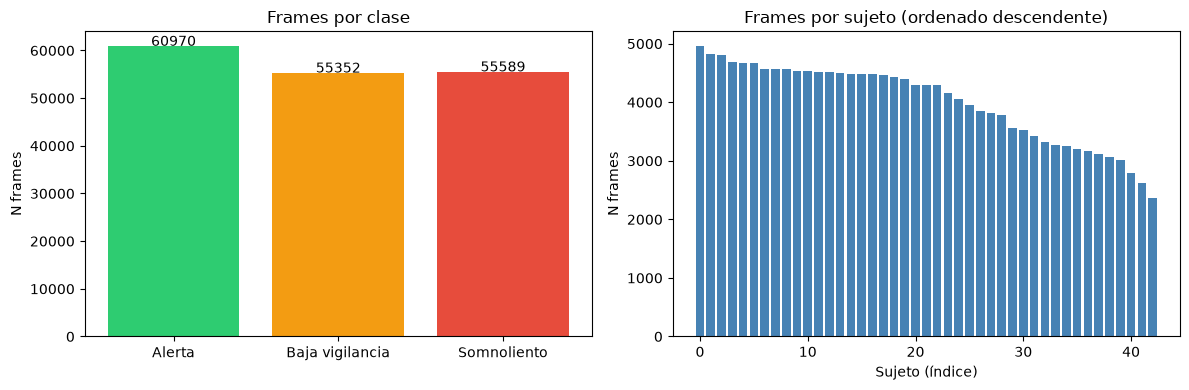

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de frames por clase
counts = [(y == i).sum() for i in range(3)]
axes[0].bar(CLASS_NAMES, counts, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Frames por clase')
axes[0].set_ylabel('N frames')
for i, c in enumerate(counts):
    axes[0].text(i, c + 10, str(c), ha='center', fontsize=10)

# Distribución de frames por sujeto
unique_subj, subj_counts = np.unique(subjects, return_counts=True)
axes[1].bar(range(len(unique_subj)), sorted(subj_counts, reverse=True), color='steelblue')
axes[1].set_title('Frames por sujeto (ordenado descendente)')
axes[1].set_xlabel('Sujeto (índice)')
axes[1].set_ylabel('N frames')

plt.tight_layout()
plt.savefig('../docs/distribucion_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sample de crops por clase

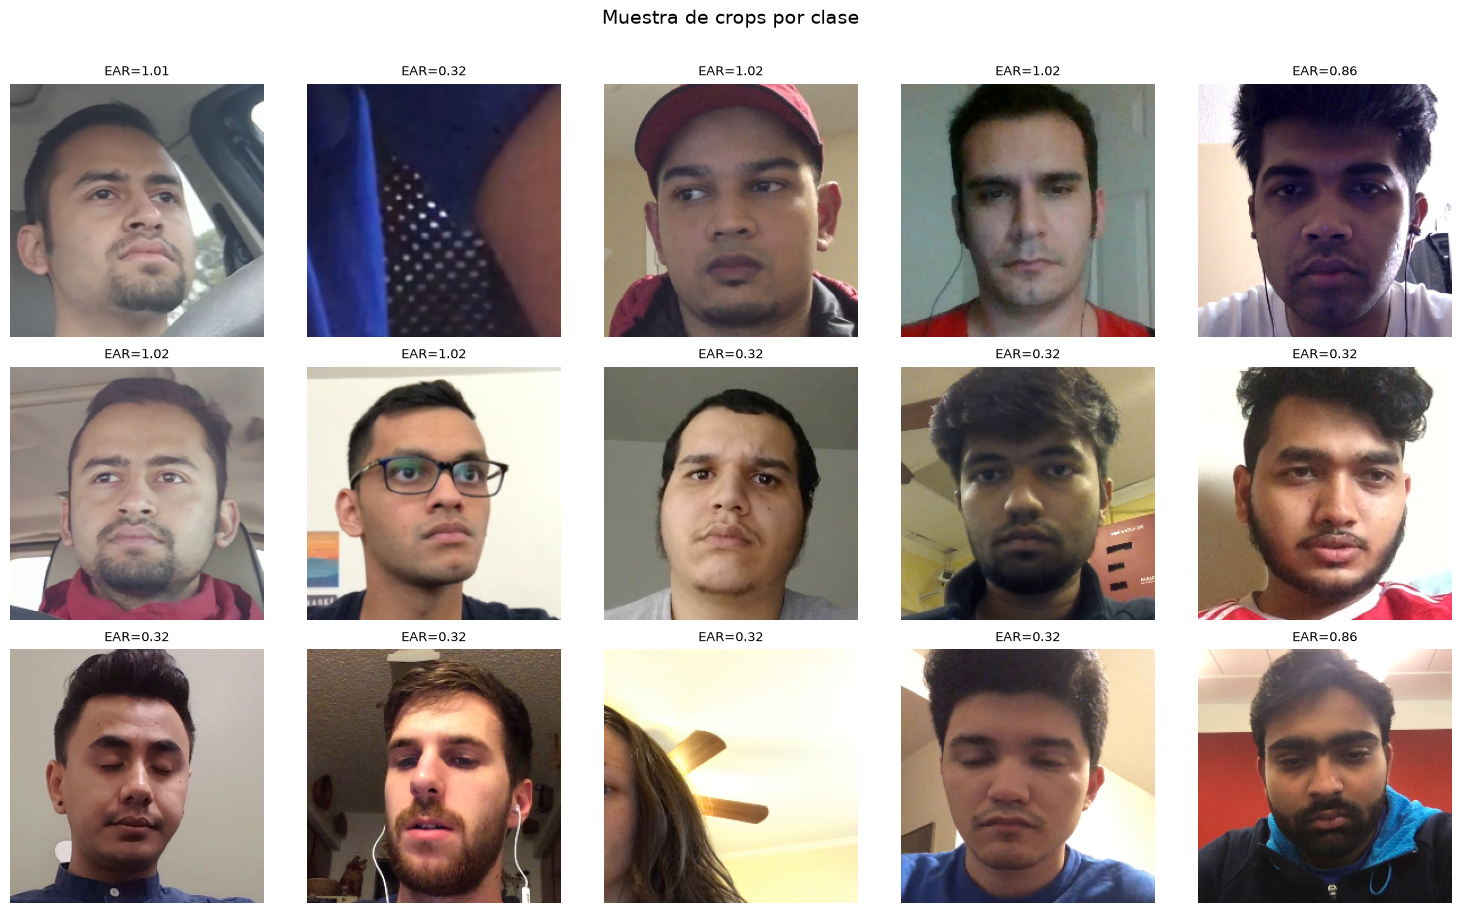

In [9]:
rng = np.random.default_rng(42)
N_SHOW = 5

fig, axes = plt.subplots(3, N_SHOW, figsize=(3*N_SHOW, 9))

with h5py.File(H5, 'r') as f:
    X_ds = f['X']
    for row, (lbl, name) in enumerate(enumerate(CLASS_NAMES)):
        idxs = np.where(y == lbl)[0]
        chosen = np.sort(rng.choice(idxs, size=min(N_SHOW, len(idxs)), replace=False))
        for col, idx in enumerate(chosen):
            axes[row, col].imshow(X_ds[idx])   # lee 1 crop del disco
            axes[row, col].set_title(f'EAR={ear[idx]:.2f}', fontsize=9)
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(name, fontsize=12, rotation=90, labelpad=40)

plt.suptitle('Muestra de crops por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Distribución de EAR por clase

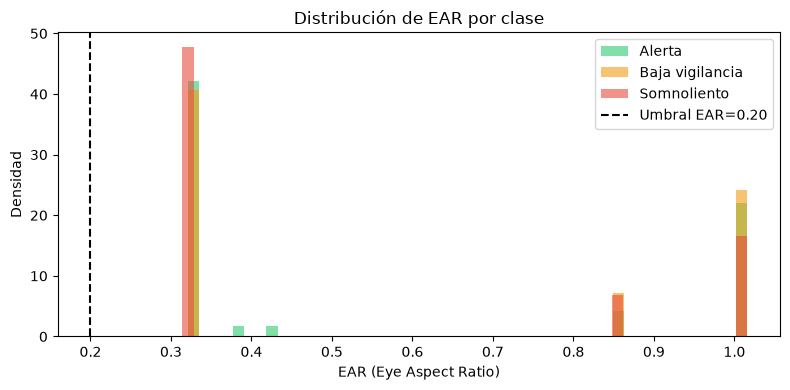

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
for lbl, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    mask = y == lbl
    ax.hist(ear[mask], bins=50, alpha=0.6, label=name, color=color, density=True)

ax.axvline(0.20, color='k', linestyle='--', label='Umbral EAR=0.20')
ax.set_xlabel('EAR (Eye Aspect Ratio)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de EAR por clase')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Optimizar HDF5 para entrenamiento

Re-chunkea `crops.h5` a 1 imagen/chunk y copia a `~/drowsiness_crops.h5` (disco Linux).
Sin este paso el DataLoader con shuffle lee ~77 MB por imagen — el entrenamiento tarda horas.

**Tarda ~20-40 min. El progreso se muestra en tiempo real.**

In [ ]:
%%bash
cd ..
python -m src.data.optimize_h5 --input data/processed/crops.h5 --to-home

Origen: 171911 crops (224, 224, 3)
  171911/171911
Guardado: /home/lilidl/drowsiness_crops.h5  (17870 MB)

Apuntá la variable H5 de las notebooks a:
  /home/lilidl/drowsiness_crops.h5


: 